# 10 – CNN Optimization

In this notebook, we improve the convolutional neural network introduced in Week 6 by applying common deep learning optimization techniques.

The goal is not only to increase model performance, but also to improve generalization and create a more reliable training pipeline.

## Goals

By the end of this notebook, we can:

- improve the CNN architecture
- introduce a validation set
- apply dropout regularization
- implement early stopping
- monitor training and validation performance
- compare the optimized CNN with the original baseline

In [1]:
import numpy as np
import librosa
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Training will run on CPU.")

Using device: cpu
CUDA is not available. Training will run on CPU.


In [3]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

genres = ["rock", "classical", "jazz", "metal"]
samples_per_genre = 100

target_frames = 130
n_mels = 128

## Why Model Optimization?

Building a neural network is only the first step.

In practice, much of deep learning focuses on improving how a model is trained rather than simply increasing its size.

Optimization techniques such as validation splits, dropout, and early stopping help models generalize better to unseen data instead of memorizing the training data.

This notebook introduces these techniques and evaluates their impact on model performance.

## Improvements over the First CNN

Compared to the CNN introduced in Week 6, several improvements have been implemented.

| Week 6 | Week 10 |
|---------|----------|
| Simple CNN | Deeper CNN |
| No validation set | Dedicated validation set |
| No dropout | Dropout regularization |
| Fixed number of epochs | Early stopping |
| Basic monitoring | Train & validation monitoring |

In [4]:
print("Data path exists:", data_path.exists())

for genre in genres:
    genre_path = data_path / genre
    print(
        genre,
        "exists:", genre_path.exists(),
        "files:", len(list(genre_path.glob("*.wav")))
    )

Data path exists: True
rock exists: True files: 100
classical exists: True files: 100
jazz exists: True files: 100
metal exists: True files: 100


## 1. Dataset Preparation

As in Week 6, each audio file is converted into a fixed-size Mel-spectrogram.

The resulting dataset is normalized and prepared for use with PyTorch.

In [5]:
def compute_mel_spectrogram(file_path, sr=22050, n_mels=128, target_frames=130):
    y, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] >= target_frames:
        mel_db = mel_db[:, :target_frames]
    else:
        pad_width = target_frames - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )

    return mel_db

In [6]:
X = []
y = []

for genre in genres:
    genre_path = data_path / genre
    files = list(genre_path.glob("*.wav"))[:samples_per_genre]

    for file in files:
        try:
            mel = compute_mel_spectrogram(
                file,
                n_mels=n_mels,
                target_frames=target_frames
            )

            X.append(mel)
            y.append(genre)

        except Exception as e:
            print("Error with file:", file)
            print(e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

/tmp/ipykernel_1158/1335188984.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=sr)
/home/richard/Projects/Music-Genre-Classification-with-CNNs-and-Audio-Based-Song-Recommendation/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error with file: ../data/raw/gtzan/Data/genres_original/jazz/jazz.00054.wav

X shape: (399, 128, 130)
y shape: (399,)


In [7]:
X_mean = X.mean()
X_std = X.std()

X = (X - X_mean) / X_std

print("Mean after normalization:", X.mean())
print("Std after normalization:", X.std())

Mean after normalization: -1.6003048e-07
Std after normalization: 1.0


In [8]:
X = X[:, np.newaxis, :, :]

print("CNN input shape:", X.shape)

CNN input shape: (399, 1, 128, 130)


In [9]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['classical' 'jazz' 'metal' 'rock']
Encoded labels: [0 1 2 3]


## 2. Train, Validation and Test Split

Instead of splitting the data into only training and test sets, we now introduce a validation set.

The validation set is not used for learning. Instead, it provides an unbiased estimate of model performance during training.

This allows us to detect overfitting before evaluating the final model on the test set.

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (239, 1, 128, 130)
Validation: (80, 1, 128, 130)
Test: (80, 1, 128, 130)


In [11]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

## 3. Improved CNN Architecture

The CNN architecture has been expanded with additional convolutional layers and dropout regularization.

Convolutional layers learn increasingly complex patterns from Mel-spectrograms, while dropout randomly disables neurons during training.

This prevents the network from relying too heavily on individual neurons and improves generalization.

In [12]:
class CNNV2(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = CNNV2(num_classes=len(genres)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

CNNV2(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


## 4. Training Strategy

The model is trained using:

- Cross Entropy Loss
- Adam optimizer
- Validation monitoring
- Early stopping

Unlike the previous notebook, training is no longer stopped after a fixed number of epochs.

Instead, the validation loss determines when training should stop.

In [14]:
def calculate_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

## Early Stopping

During training, the validation loss is monitored after each epoch.

If the validation loss does not improve for several consecutive epochs, training is stopped automatically.

This prevents unnecessary training and reduces the risk of overfitting.

In [15]:
import copy

best_epoch = 0
patience = 5
epochs_without_improvement = 0
best_val_accuracy = 0.0
best_model_state = None

num_epochs = 40

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0
    running_train_acc = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        running_train_acc += calculate_accuracy(outputs, y_batch)

    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_acc / len(train_loader)

    model.eval()
    running_val_loss = 0
    running_val_acc = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()
            running_val_acc += calculate_accuracy(outputs, y_batch)

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_acc = running_val_acc / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(avg_train_acc)
    val_accuracies.append(avg_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Train Acc: {avg_train_acc:.4f} | "
        f"Val Acc: {avg_val_acc:.4f}"
    )

    if avg_val_acc > best_val_accuracy:
        best_val_accuracy = avg_val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        print(f"New best model! Validation Accuracy: {best_val_accuracy:.4f}")

    else:
        epochs_without_improvement += 1

        print(f"No improvement ({epochs_without_improvement}/{patience})")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/40 | Train Loss: 1.3687 | Val Loss: 1.1111 | Train Acc: 0.3353 | Val Acc: 0.4750
New best model! Validation Accuracy: 0.4750
Epoch 2/40 | Train Loss: 1.0876 | Val Loss: 1.0116 | Train Acc: 0.5100 | Val Acc: 0.5500
New best model! Validation Accuracy: 0.5500
Epoch 3/40 | Train Loss: 0.9579 | Val Loss: 0.9146 | Train Acc: 0.5731 | Val Acc: 0.5375
No improvement (1/5)
Epoch 4/40 | Train Loss: 0.8397 | Val Loss: 0.8078 | Train Acc: 0.6778 | Val Acc: 0.6375
New best model! Validation Accuracy: 0.6375
Epoch 5/40 | Train Loss: 0.6846 | Val Loss: 0.7247 | Train Acc: 0.7278 | Val Acc: 0.7125
New best model! Validation Accuracy: 0.7125
Epoch 6/40 | Train Loss: 0.5666 | Val Loss: 0.7020 | Train Acc: 0.7953 | Val Acc: 0.6750
No improvement (1/5)
Epoch 7/40 | Train Loss: 0.5435 | Val Loss: 1.0098 | Train Acc: 0.7561 | Val Acc: 0.6625
No improvement (2/5)
Epoch 8/40 | Train Loss: 0.4823 | Val Loss: 0.7395 | Train Acc: 0.8081 | Val Acc: 0.7375
New best model! Validation Accuracy: 0.7375
Epoch

## Interpreting the Learning Curves

The training loss decreases steadily throughout training.

The validation loss initially follows the same trend but eventually stabilizes.

When the gap between training and validation performance becomes too large, the model begins to memorize the training data instead of learning patterns that generalize well.

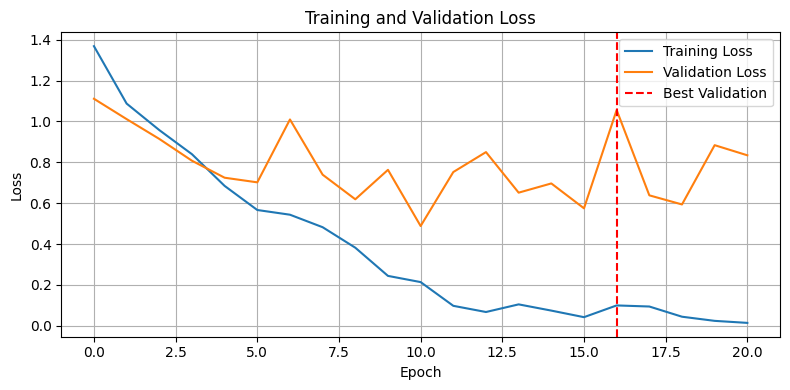

In [16]:
plt.figure(figsize=(8,4))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label="Best Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

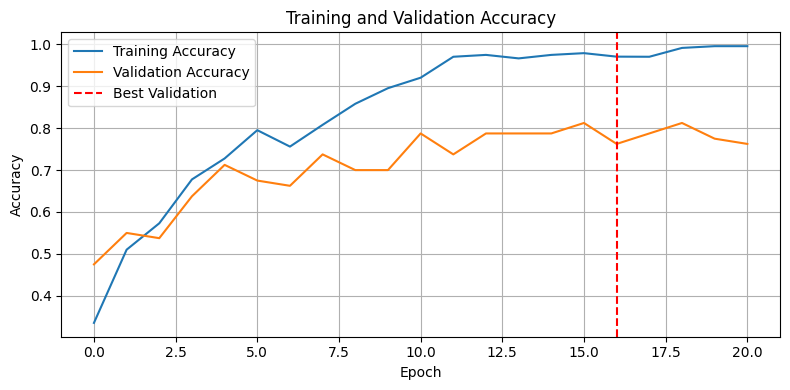

In [17]:
plt.figure(figsize=(8,4))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label="Best Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
model.load_state_dict(best_model_state)

print(f"Loaded best model from epoch {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Loaded best model from epoch 16
Best validation accuracy: 0.8125


## 6. Model Evaluation

After training, the optimized CNN is evaluated on the test dataset.

Performance is measured using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Together, these metrics provide a comprehensive view of model performance.

In [19]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8


### Classification Report

While accuracy summarizes the overall performance, the classification report provides detailed metrics for each individual genre.

This makes it possible to identify classes that remain difficult to distinguish.

In [20]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

   classical       0.81      0.85      0.83        20
        jazz       0.73      0.55      0.63        20
       metal       0.95      0.95      0.95        20
        rock       0.71      0.85      0.77        20

    accuracy                           0.80        80
   macro avg       0.80      0.80      0.80        80
weighted avg       0.80      0.80      0.80        80



### Confusion Matrix

The confusion matrix visualizes where classification errors occur.

Correct predictions appear along the diagonal, while off-diagonal values indicate genre confusions.

This visualization often reveals patterns that are not obvious from accuracy alone.

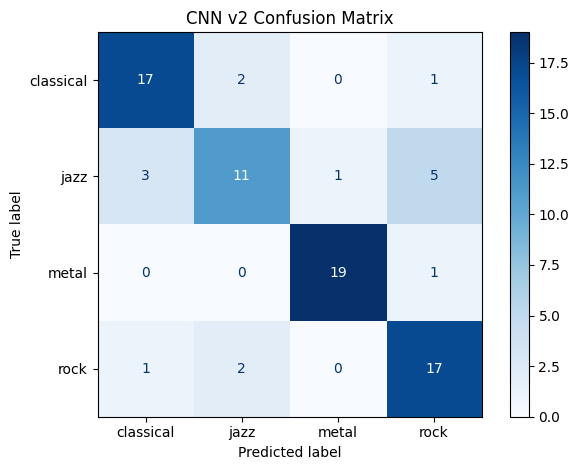

In [21]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("CNN v2 Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Comparing Both CNN Models

Although both models are based on convolutional neural networks, the optimized version introduces several improvements to the training procedure.

The comparison below summarizes the main differences.

In [22]:
cnn_v1_accuracy = 0.85
cnn_v2_accuracy = test_accuracy

comparison = pd.DataFrame({
    "Model": ["CNN v1", "CNN v2"],
    "Accuracy": [cnn_v1_accuracy, cnn_v2_accuracy]
})

comparison

,Model,Accuracy
0,CNN v1,0.85
1,CNN v2,0.80


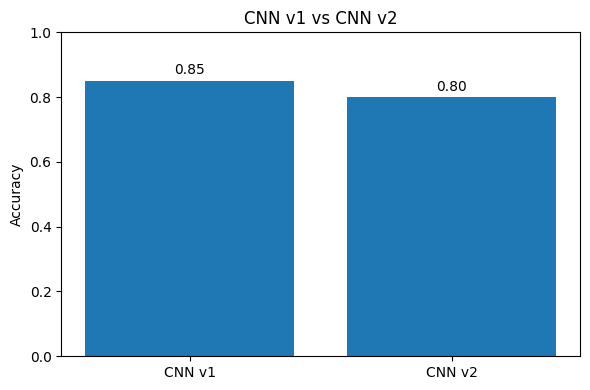

In [23]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("CNN v1 vs CNN v2")

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

Although the optimized CNN achieved a slightly lower test accuracy, the training procedure is considerably more reliable.

The use of validation data, dropout, and early stopping makes the results more reproducible and reduces the likelihood of overfitting.

This notebook demonstrates that good machine learning practice is not solely about maximizing accuracy, but about developing models that generalize well to unseen data.

## Observations

- The optimized CNN successfully learned meaningful patterns from Mel-spectrograms.
- Validation monitoring provided better insight into the training process.
- Dropout reduced the risk of overfitting by improving model generalization.
- Early stopping prevented unnecessary training once validation performance stopped improving.
- Although the final accuracy is slightly lower than in Week 6, the training procedure is more robust and reproducible.

## Additional Observations

- The optimized CNN reached nearly perfect training accuracy, while the validation accuracy saturated at approximately 81%.
- This indicates that the model began to overfit the training data despite the use of dropout.
- Early stopping successfully prevented unnecessary training after the validation accuracy stopped improving.
- Increasing the model complexity did not automatically improve the final test accuracy.
- This demonstrates that model architecture alone is not sufficient; data quality, dataset size, and hyperparameter selection also strongly influence performance.

## Reflection

One of the most important lessons from this notebook is that increasing model complexity does not automatically improve performance.

Careful optimization, validation, and regularization are often more important than simply adding more layers.

The optimized training pipeline developed here provides a stronger foundation for future deep learning experiments.

## Week 10 Summary

This week focused on improving the CNN introduced in Week 6.

We:

- expanded the CNN architecture
- introduced a validation dataset
- applied dropout regularization
- implemented early stopping
- monitored training and validation performance
- compared the optimized model with the original CNN

The optimized training pipeline emphasizes reliable model development and better generalization rather than simply maximizing training accuracy.

These techniques represent common best practices in modern deep learning workflows.